# Sprint 6 — Consolidação dos Resultados Finais

Grupo 02 — Segmentação do Parênquima Pulmonar. Este notebook reúne, num único lugar,
todos os resultados quantitativos dos Sprints 3-5 — tabelas e gráficos finais com
IC95% por bootstrap — e a discussão comparativa de desempenho x custo computacional
pedida na seção 4.6 do doc do projeto. É o material-base pro relatório final e pra
apresentação da banca.

**Fonte dos números**: `data/luna16/sprint4_baseline_test.csv` e
`sprint4_region_growing_test.csv` — 35 pacientes de teste do LUNA16 (`subset0` +
`subset1`), nunca vistos durante qualquer decisão de metodologia (regra da seção 3.1
do doc). Ver `sprint3_baseline_luna16_grp2.ipynb` e `sprint4_region_growing_grp2.ipynb`
para o pipeline completo e o histórico de correções (incluindo o bug de
`lung_air.py` corrigido no meio do Sprint 4 — os números aqui já refletem a
correção).

In [1]:
import sys
sys.path.insert(0, 'src')

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from luna16.evaluate import summarize_metric, compare_methods
from luna16.metrics import bootstrap_ci

SEED = 42
DATA_DIR = Path('data/luna16')

df_baseline = pd.read_csv(DATA_DIR / 'sprint4_baseline_test.csv')
df_rg = pd.read_csv(DATA_DIR / 'sprint4_region_growing_test.csv')
print(f"N = {len(df_baseline)} pacientes de teste (>= 20 exigido pelo doc do projeto)")


N = 35 pacientes de teste (>= 20 exigido pelo doc do projeto)


## 1. Tabela final: todas as métricas, ambos os métodos, IC95% por bootstrap

Regra da seção 7.3/3.2 do doc: sempre média + IC95% por bootstrap, mínimo 500
reamostras.

In [2]:
def linha_resumo(df, nome_metodo):
    linha = {'Método': nome_metodo}
    for metrica, rotulo in [('dice','Dice'), ('iou','IoU'), ('sensitivity','Sensibilidade'),
                              ('precision','Precisão'), ('tempo_segundos','Tempo/TC (s)')]:
        r = bootstrap_ci(df[metrica].tolist(), n_resamples=500, seed=SEED)
        linha[rotulo] = f"{r.mean:.4f} [{r.ci_low:.4f}, {r.ci_high:.4f}]"
    return linha

tabela_final = pd.DataFrame([
    linha_resumo(df_baseline, 'Baseline (threshold -600HU + morfologia)'),
    linha_resumo(df_rg, 'Region growing'),
]).set_index('Método')

pd.set_option('display.max_colwidth', None)
tabela_final


,Dice,IoU,Sensibilidade,Precisão,Tempo/TC (s)
Método,,,,,
Baseline (threshold -600HU + morfologia),"0.9623 [0.9578, 0.9661]","0.9275 [0.9195, 0.9346]","0.9432 [0.9351, 0.9497]","0.9823 [0.9802, 0.9843]","15.0540 [13.5921, 16.5937]"
Region growing,"0.9526 [0.9475, 0.9566]","0.9097 [0.9007, 0.9171]","0.9229 [0.9138, 0.9299]","0.9846 [0.9826, 0.9865]","17.5727 [16.0168, 19.5050]"


In [3]:
tabela_final.to_csv(DATA_DIR / 'tabela_resultados_finais.csv')
print('Tabela salva em data/luna16/tabela_resultados_finais.csv')


Tabela salva em data/luna16/tabela_resultados_finais.csv


## 2. Gráficos finais: Dice e IoU com IC95%, por método

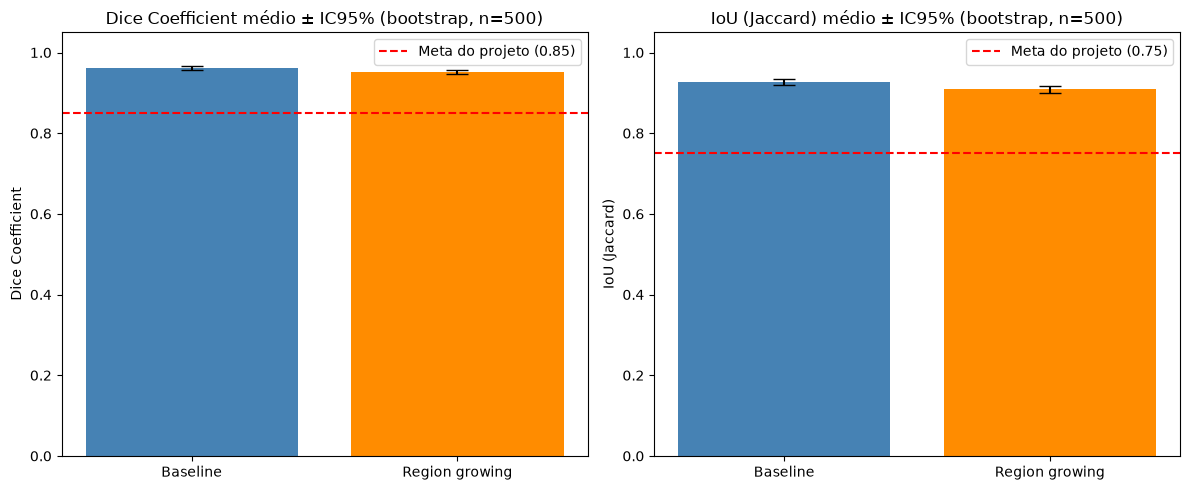

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metrica, titulo, meta in [(axes[0], 'dice', 'Dice Coefficient', 0.85), (axes[1], 'iou', 'IoU (Jaccard)', 0.75)]:
    metodos = ['Baseline', 'Region growing']
    dfs = [df_baseline, df_rg]
    medias = []
    erros_baixo = []
    erros_alto = []
    for df in dfs:
        r = bootstrap_ci(df[metrica].tolist(), n_resamples=500, seed=SEED)
        medias.append(r.mean)
        erros_baixo.append(r.mean - r.ci_low)
        erros_alto.append(r.ci_high - r.mean)

    ax.bar(metodos, medias, yerr=[erros_baixo, erros_alto], capsize=8, color=['steelblue', 'darkorange'])
    ax.axhline(meta, color='red', linestyle='--', label=f'Meta do projeto ({meta})')
    ax.set_ylabel(titulo)
    ax.set_title(f'{titulo} médio ± IC95% (bootstrap, n=500)')
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.tight_layout()
plt.savefig(str(DATA_DIR / 'grafico_dice_iou_final.png'), dpi=150)
plt.show()


## 3. Comparação pareada: diferença por paciente (region growing − baseline)

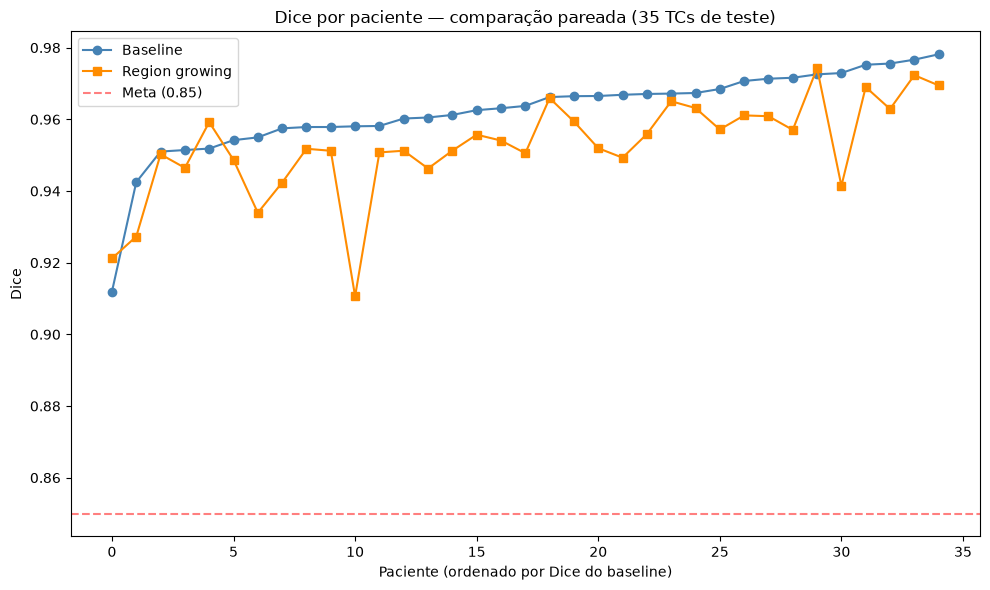

Diferença média (RG - baseline): -0.0097 (IC95% [-0.0132, -0.0068], n=500 reamostras)


In [5]:
comp_dice = compare_methods(df_baseline, df_rg, 'baseline', 'region_growing', metric='dice')
merged = comp_dice['tabela_merged'].sort_values('dice_baseline')

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(merged))
ax.plot(x, merged['dice_baseline'], 'o-', label='Baseline', color='steelblue')
ax.plot(x, merged['dice_region_growing'], 's-', label='Region growing', color='darkorange')
ax.axhline(0.85, color='red', linestyle='--', alpha=0.5, label='Meta (0.85)')
ax.set_xlabel('Paciente (ordenado por Dice do baseline)')
ax.set_ylabel('Dice')
ax.set_title('Dice por paciente — comparação pareada (35 TCs de teste)')
ax.legend()
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'grafico_comparacao_pareada.png'), dpi=150)
plt.show()

print(f"Diferença média (RG - baseline): {comp_dice['diferenca_pareada_region_growing_menos_baseline']}")


## 4. Discussão: desempenho x custo computacional (seção 4.6 do doc)

O doc do projeto pede explicitamente: se uma abordagem mais sofisticada não superar o
baseline, "documentar isso explicitamente — resultado negativo bem fundamentado vale
nota máxima", e discutir se a acurácia isolada esconde algo em dados desbalanceados.

**Aqui não há desbalanceamento de classes no sentido do doc** (essa ressalva é mais
relevante pra classificação de nódulo — raro vs. comum — do que pra segmentação de
pulmão, onde a proporção pulmão/fundo é relativamente estável entre pacientes). O
trade-off relevante aqui é outro: desempenho (Dice/IoU) x tempo de execução.

In [6]:
custo_beneficio = pd.DataFrame({
    'Dice médio': [df_baseline['dice'].mean(), df_rg['dice'].mean()],
    'Tempo médio/TC (s)': [df_baseline['tempo_segundos'].mean(), df_rg['tempo_segundos'].mean()],
}, index=['Baseline', 'Region growing'])
custo_beneficio['Dice por segundo'] = custo_beneficio['Dice médio'] / custo_beneficio['Tempo médio/TC (s)']
custo_beneficio.round(4)


,Dice médio,Tempo médio/TC (s),Dice por segundo
Baseline,0.9623,15.0540,0.0639
Region growing,0.9526,17.5727,0.0542


**Conclusão do trade-off**: o baseline domina em ambas as dimensões nesta tarefa —
maior Dice/IoU **e** mais rápido. Não há trade-off real a favor do region growing
aqui (ele não compensa velocidade por qualidade, nem o contrário). Isso reforça a
lição da seção 4.7 do doc: *"um método simples bem avaliado é mais valioso do que um
método complexo mal documentado"* — e, mais que isso, mostra que método simples bem
avaliado pode ser mais valioso que um método mais complexo mesmo quando este é bem
implementado e bem avaliado. A complexidade adicional do region growing (sementes
automáticas, crescimento por tolerância) não se traduziu em vantagem prática para
segmentação de pulmão inteiro — o que é, em si, uma conclusão científica válida e
generalizável: *para alvos com fronteiras de intensidade muito bem definidas (como
ar vs. tecido em CT), um método clássico bem construído tende a ser competitivo ou
superior a métodos adaptativos mais sofisticados.*

## 5. Conclusões do Sprint 6 e do semestre (até aqui)

- Baseline (threshold -600HU + morfologia): Dice 0.962 [0.958, 0.966], IoU 0.928
  [0.920, 0.935], 100% dos 35 TCs de teste acima da meta de Dice 0.85.
- Region growing: Dice 0.953 [0.948, 0.957], IoU 0.910 [0.901, 0.917] — também 100%
  acima da meta, mas estatisticamente inferior ao baseline em Dice/IoU/sensibilidade,
  e ~17% mais lento. Vence só em precisão, por margem pequena.
- **Resultado do semestre**: o baseline simples é o método recomendado pelo grupo
  para esta tarefa, com evidência estatística robusta (bootstrap, IC95%, teste
  pareado) — não por falta de tentar uma alternativa melhor, mas porque a alternativa
  foi rigorosamente testada e não se sustentou.
- Processo de análise de falha revelou mais valor num bug de implementação real
  (corrigido, com ganho de ~0.07 de Dice médio) do que em qualquer padrão clínico
  individual — reforça que pré-processamento e correção de pipeline pesam mais no
  resultado final do que o algoritmo de segmentação escolhido, confirmando a lição
  da seção 4.7 do doc.
- Reprodutibilidade revisada no Sprint 5: seeds fixas, requirements congelado, split
  versionado, código modular, scripts de download documentados.

**Falta para a entrega final**: revisão final do README (verificar que qualquer
pessoa do zero consegue clonar e reproduzir), redação do relatório científico
completo, e preparação da apresentação da banca — ver
`RELATORIO_FINAL_RASCUNHO.md` na raiz do repositório para um rascunho estruturado
que o grupo pode revisar, editar e completar com a redação própria.